In [1]:
# Descomentar en caso de requerir instalación de paquetes
# !pip install cobra
# !pip install gurobipy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cobra
from steadycom import SteadyCom, SteadyComVA, build_steadycom_model

# Taller 7: SteadyCom para simular comunidades

In [2]:
# Importar modelos
m1 = cobra.io.read_sbml_model("e_coli_core.xml")
m2 = cobra.io.read_sbml_model("e_coli_core.xml")

# Renombrar organismos
m1.id = "act_ko" # Productor
m2.id = "glc_ko" # Consumidor

Restricted license - for non-production use only - expires 2026-11-23


In [3]:
# Modificaciones genéticas
# Productor: no puede importar acetato, solo secretar
m1.reactions.get_by_id("ACt2r").upper_bound = 0.0

# Consumidor: no puede usar glucosa (knockout del sistema de transporte fosfotransferasa)
m2.reactions.get_by_id("GLCpts").knock_out()

In [4]:
# Crear medio de cultivo
for m in [m1, m2]:
    m.reactions.get_by_id("EX_glc__D_e").lower_bound = -10.0  # uptake de glucosa
    m.reactions.get_by_id("EX_o2_e").lower_bound     = -10.0  # uptake de O2
    m.reactions.get_by_id("EX_ac_e").lower_bound     = -10.0  # uptake de acetato
    m.reactions.get_by_id("EX_nh4_e").lower_bound    = -10.0  # uptake de NH4
    m.reactions.get_by_id("EX_pi_e").lower_bound     = -10.0  # uptake de Pi


### a) Crecimiento individual de las *E. coli*

In [5]:
sol_ind1 = m1.optimize()
sol_ind2 = m2.optimize()

if sol_ind1.status == 'optimal':
    print(f"Crecimiento individual productor: {sol_ind1.objective_value:.4f} 1/h")
else:
    print('Modelo productor infactible')
if sol_ind2.status == 'optimal':
    print(f"Crecimiento individual consumidor: {sol_ind2.objective_value:.4f} 1/h")
else:
    print('Modelo consumidor infactible')

Crecimiento individual productor: 0.5591 1/h
Crecimiento individual consumidor: 0.1238 1/h


### b) Construir comunidad y simular usando SteadyCom

In [6]:
community = build_steadycom_model([m1, m2], ["act_ko", "glc_ko"])

In [7]:
medium_o2_low = {"EX_o2_e": (-10.0, 1000), 'EX_ac_e': (0.0, 1000), 'EX_glc__D_e': (-10.0, 1000),
                 'EX_nh4_e': (-10.0, 1000), 'EX_pi_e': (-10.0, 1000)}

sol = SteadyCom(community, medium=medium_o2_low)
print(f"Estado: {sol.status.name}")
print(f"mu comunitario: {sol.fobj:.4f}")
print(f"Abundancia relativa productor: {sol.values['x_act_ko']:.4f}")
print(f"Abundancia relativa consumidor: {sol.values['x_glc_ko']:.4f}")

print('\nFlujos de sustratos comunitarios:\n')
print(f"Glucosa: {sol.values['EX_glc__D_e']:.4f} mM/gDW/h")
print(f"O2: {sol.values['EX_o2_e']:.4f} mM/gDW/h")
print(f"Acetato: {sol.values['EX_ac_e']:.4f} mM/gDW/h")
print(f"NH4: {sol.values['EX_nh4_e']:.4f} mM/gDW/h")
print(f"Pi: {sol.values['EX_pi_e']:.4f} mM/gDW/h")

Estado: OPTIMAL
mu comunitario: 0.5586
Abundancia relativa productor: 0.9989
Abundancia relativa consumidor: 0.0011

Flujos de sustratos comunitarios:

Glucosa: -9.9874 mM/gDW/h
O2: -10.0000 mM/gDW/h
Acetato: 9.8887 mM/gDW/h
NH4: -3.0459 mM/gDW/h
Pi: -2.0549 mM/gDW/h


### c) Simular comunidad relajando el consumo de oxígeno y bloqueadolo

In [8]:
medium_o2_rich = {"EX_o2_e": (-20.0, 1000), 'EX_ac_e': (0.0, 1000), 'EX_glc__D_e': (-10.0, 1000),
                 'EX_nh4_e': (-10.0, 1000), 'EX_pi_e': (-10.0, 1000)}
sol2 = SteadyCom(community, medium=medium_o2_rich)

print(f"Estado: {sol2.status.name}")
print(f"mu comunitario: {sol2.fobj:.4f}")
print(f"Abundancia relativa productor: {sol2.values['x_act_ko']:.4f}")
print(f"Abundancia relativa consumidor: {sol2.values['x_glc_ko']:.4f}")

print('\nFlujos de sustratos comunitarios:\n')
print(f"Glucosa: {sol2.values['EX_glc__D_e']:.4f} mM/gDW/h")
print(f"O2: {sol2.values['EX_o2_e']:.4f} mM/gDW/h")
print(f"Acetato: {sol2.values['EX_ac_e']:.4f} mM/gDW/h")
print(f"NH4: {sol2.values['EX_nh4_e']:.4f} mM/gDW/h")
print(f"Pi: {sol2.values['EX_pi_e']:.4f} mM/gDW/h")

Estado: OPTIMAL
mu comunitario: 0.8320
Abundancia relativa productor: 0.9929
Abundancia relativa consumidor: 0.0071

Flujos de sustratos comunitarios:

Glucosa: -9.9947 mM/gDW/h
O2: -20.0000 mM/gDW/h
Acetato: 1.7995 mM/gDW/h
NH4: -4.5369 mM/gDW/h
Pi: -3.0608 mM/gDW/h


In [9]:
medium_wo_o2 = {"EX_o2_e": (0, 1000), 'EX_ac_e': (0.0, 1000), 'EX_glc__D_e': (-10.0, 1000),
                 'EX_nh4_e': (-10.0, 1000), 'EX_pi_e': (-10.0, 1000)}
sol3 = SteadyCom(community, medium=medium_wo_o2)

print(f"Estado: {sol3.status.name}")
print(f"mu comunitario: {sol3.fobj:.4f}")
print(f"Abundancia relativa productor: {sol3.values['x_act_ko']:.4f}")
print(f"Abundancia relativa consumidor: {sol3.values['x_glc_ko']:.4f}")

print('\nFlujos de sustratos comunitarios:\n')
print(f"Glucosa: {sol3.values['EX_glc__D_e']:.4f} mM/gDW/h")
print(f"O2: {sol3.values['EX_o2_e']:.4f} mM/gDW/h")
print(f"Acetato: {sol3.values['EX_ac_e']:.4f} mM/gDW/h")
print(f"NH4: {sol3.values['EX_nh4_e']:.4f} mM/gDW/h")
print(f"Pi: {sol3.values['EX_pi_e']:.4f} mM/gDW/h")

Estado: OPTIMAL
mu comunitario: 0.2109
Abundancia relativa productor: 1.0000
Abundancia relativa consumidor: 0.0000

Flujos de sustratos comunitarios:

Glucosa: -10.0000 mM/gDW/h
O2: 0.0000 mM/gDW/h
Acetato: 8.4650 mM/gDW/h
NH4: -1.1720 mM/gDW/h
Pi: -0.7760 mM/gDW/h


### d) Hacer gráfico de envolventes de crecimiento comunitario

In [10]:
# El máximo crecimiento comunitario en el medio original
optimum =  SteadyCom(community, medium = medium_o2_low).fobj

In [11]:
var_df = pd.DataFrame(columns = ['Growth_rate', 'prod_low', 'prod_high', 'cons_low', 'cons_high'])
j = 0
for i in np.linspace(0.8, 1, 100):
    growth_rate = optimum * i
    var_df.loc[j, 'Growth_rate'] = growth_rate
    variability = SteadyComVA(community, obj_frac=i, medium=medium_o2_low)
    var_df.loc[j, 'prod_low']  = variability['act_ko'][0]
    var_df.loc[j, 'prod_high'] = variability['act_ko'][1]
    var_df.loc[j, 'cons_low']  = variability['glc_ko'][0]
    var_df.loc[j, 'cons_high'] = variability['glc_ko'][1]
    j += 1


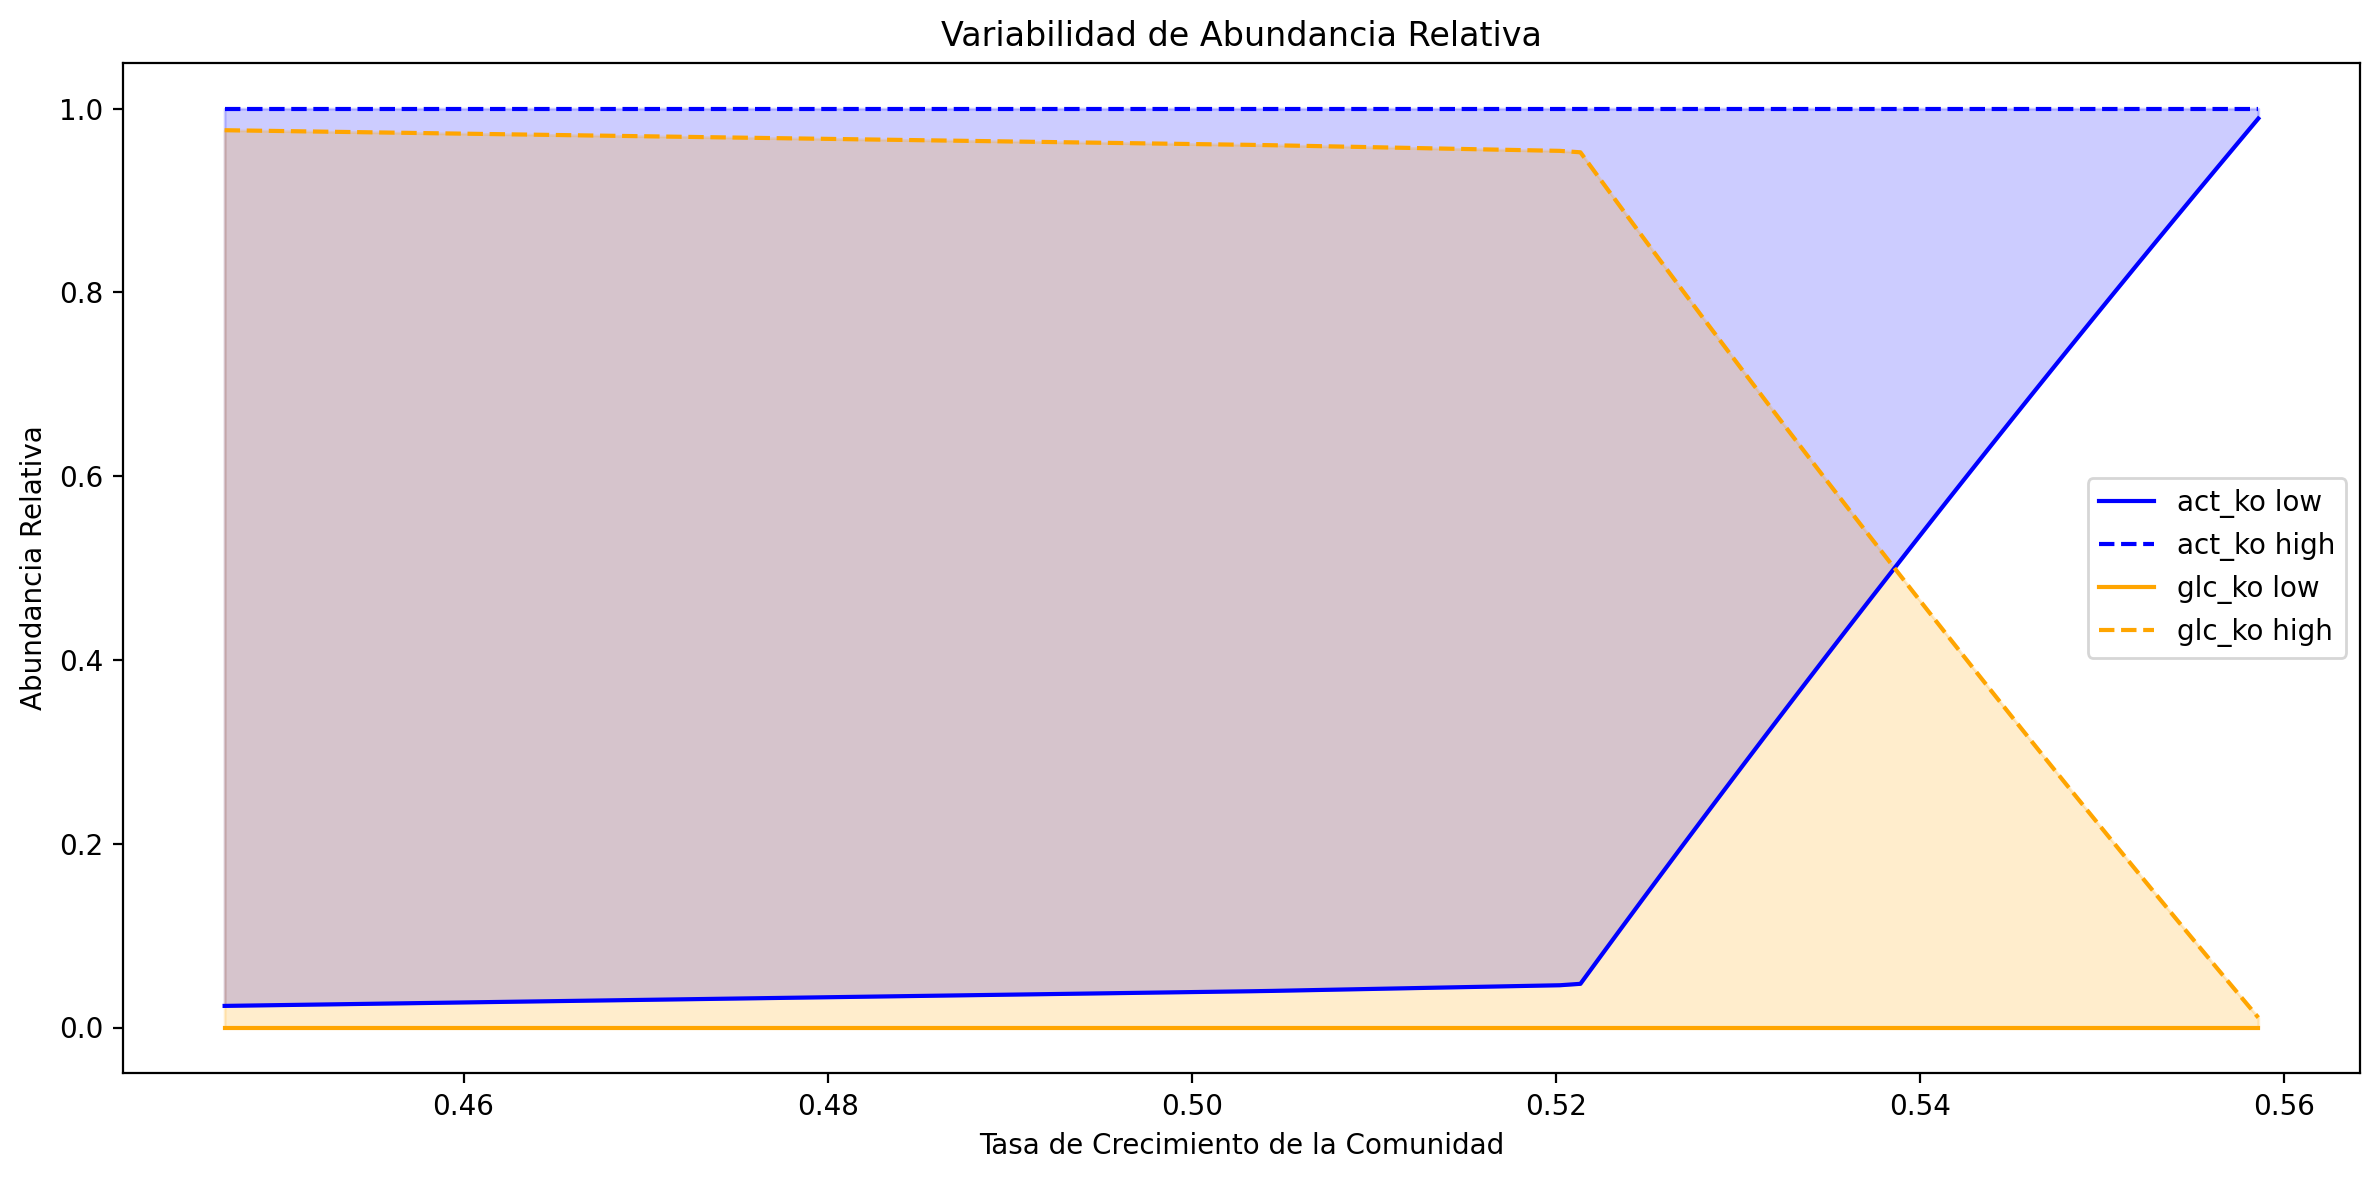

In [12]:
# # Rutina para evitar NaN o inf en el DataFrame
var_df = var_df.apply(pd.to_numeric, errors='coerce')
var_df = var_df.dropna()

fig, ax = plt.subplots(1, figsize=(12, 6), dpi=200)

ax.plot(var_df['Growth_rate'], var_df['prod_low'], label='act_ko low', color='blue', linestyle='-')
ax.plot(var_df['Growth_rate'], var_df['prod_high'], label='act_ko high', color='blue', linestyle='--')
ax.fill_between(var_df['Growth_rate'], var_df['prod_low'], var_df['prod_high'], color='blue', alpha=0.2)

ax.plot(var_df['Growth_rate'], var_df['cons_low'], label='glc_ko low', color='orange', linestyle='-')
ax.plot(var_df['Growth_rate'], var_df['cons_high'], label='glc_ko high', color='orange', linestyle='--')
ax.fill_between(var_df['Growth_rate'], var_df['cons_low'], var_df['cons_high'], color='orange', alpha=0.2)

ax.set_xlabel('Tasa de Crecimiento de la Comunidad')
ax.set_ylabel('Abundancia Relativa')
ax.legend(loc='center right')
ax.set_title('Variabilidad de Abundancia Relativa')
plt.tight_layout()
plt.show()
